In [26]:
import pandas as pd

#Read in the data file
df = pd.read_csv(r"C:\Users\Toror\OneDrive\Desktop\Loan.csv")

# Print first 5 rows, What are the observations
print(df.head())

print("Observations:")
print("i) Data has missing values")
print("ii) Applicant income is more compared to coapplicant income")


    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [2]:
#shape of the dataset

print(df.shape)
print("Rows represent individual loan applications; columns represent the features/variables describing each loan")

(614, 13)
Rows represent individual loan applications; columns represent the features/variables describing each loan


In [3]:
# Data types
print(df.info())

#Importance
print ("Numeric columns can be used for calculations, statistics, and machine learning models, Text (object) columns may need cleaning, encoding, or conversion before modeling and Incorrect data types can cause errors (e.g., numbers stored as text) or misleading results")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None
Numeric columns can be used for calculations, statistics, and machine learning models, Text (object) column

In [10]:
# Summary statistics
df.describe()
# a) Average applicant income

avg_income = df['ApplicantIncome'].mean()
print("Average applicant income:", avg_income)
# b) Highest loan amount requested

max_loan_amount = df['LoanAmount'].max()
print("Highest loan amount requested:", max_loan_amount)
# c) Average loan repayment term in months

avg_loan_term = df['Loan_Amount_Term'].mean()
print("Average loan term (months):", avg_loan_term)

Average applicant income: 5403.459283387622
Highest loan amount requested: 700.0
Average loan term (months): 342.0


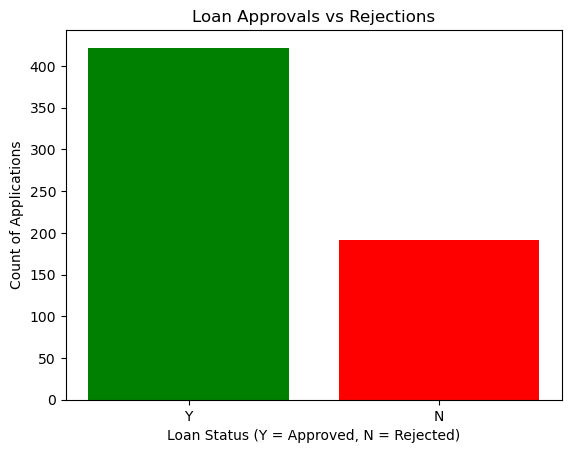

 Loan approvals are over 400 applicants


In [5]:
import matplotlib.pyplot as plt

#Count of loan Approval vs Rejection Bar Chart

loan_counts = df['Loan_Status'].value_counts()
plt.bar(loan_counts.index, loan_counts.values, color=['green', 'red'])
plt.title("Loan Approvals vs Rejections")
plt.xlabel("Loan Status (Y = Approved, N = Rejected)")
plt.ylabel("Count of Applications")
plt.show()
print (" Loan approvals are over 400 applicants")



In [ ]:
# Missing values per column
missing_counts = df.isnull().sum()

print(missing_counts)

# Column with the most missing values
most_missing = missing_counts.idxmax()
print("Column with the most missing values:", most_missing)

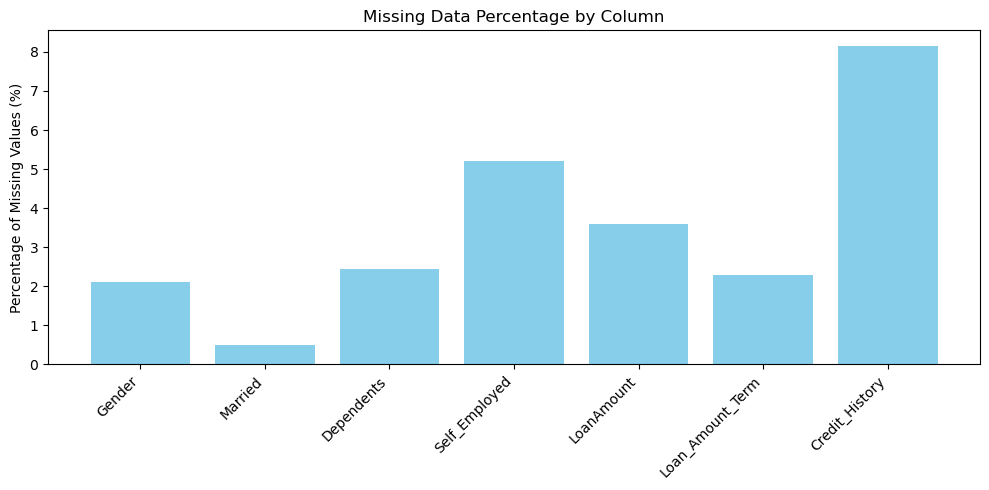

A high percentage of missing values credit History suggests inconsistent or incomplete data collection, indicating the company may need to improve its application forms or data entry procedures to ensure more reliable and usable information.


In [7]:
#Percentage of missing values

missing_percent = (df.isnull().sum() / len(df)) * 100

# Filter only columns with missing data
missing_percent = missing_percent[missing_percent > 0]

# Plot
plt.figure(figsize=(10, 5))
plt.bar(range(len(missing_percent.values)),missing_percent.values, color='skyblue')
#x-axis
plt.xticks(
    ticks=range(len(missing_percent)),
     labels=missing_percent.index,   
     rotation=45,
     ha='right'
)
    
plt.ylabel("Percentage of Missing Values (%)")
plt.title("Missing Data Percentage by Column")
plt.tight_layout()
plt.show()

print ("A high percentage of missing values credit History suggests inconsistent or incomplete data collection, indicating the company may need to improve its application forms or data entry procedures to ensure more reliable and usable information.")

In [21]:

# Check missing values before

print("Missing Values BEFORE:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")
# a) Fill missing LoanAmount with median
median_loan = df['LoanAmount'].median()
df['LoanAmount'] = df['LoanAmount'].fillna(median_loan)
print(f"LoanAmount filled with median: {median_loan}")

# b) Fill missing Loan_Amount_Term with mode

mode_term = df['Loan_Amount_Term'].mode()[0]
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(mode_term)
print(f"Loan_Amount_Term filled with mode: {mode_term}")

# c) Fill categorical columns with 'Unknown'

categorical_cols = ['Gender', 'Married', 'Self_Employed', 'Dependents']
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')
print(f"{categorical_cols} filled with 'Unknown'")
# Check missing values after
print("\n" + "="*50)
print("\nMissing Values AFTER:")
print(df.isnull().sum())

# Explanation and Recommendation of why credit history is difficult to fill

Explanation = "Credit_History is different from other columns because,Strong predictor	This column has the highest correlation with loan approval (~79% vs ~7% approval rate)"
Recommendation = " Create a separate category and treat the missing as a third state as an Unknown."

print (Explanation)
print ( Recommendation)

Missing Values BEFORE:
Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History       50
Property_Area         0
Loan_Status           0
Approved              0
dtype: int64


LoanAmount filled with median: 128.0
Loan_Amount_Term filled with mode: 360.0
['Gender', 'Married', 'Self_Employed', 'Dependents'] filled with 'Unknown'


Missing Values AFTER:
Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History       50
Property_Area         0
Loan_Status           0
Approved              0
dtype: int64
Credit_History is different from other columns because,Strong predictor	This column has the highest 

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df['ApplicantIncome'])
plt.title("Box Plot of Applicant Income")
plt.ylabel("Income")
plt.show()
#Outliers

Observation = "Loan datasets almost always show outliers in applicant income, and the box plot will reveal several very high-income applicants far above the rest of the distribution"
print (Observation)

# Loan applicant meaning for the company

Observation = "A very high applicant income usually indicates low credit risk because these applicants are more capable of repaying loans. It may also reflect business class applicants or individuals requesting larger loans. "
print (Observation)

# Should we remove those applicants from the data?

Observ = "No. These are legitimate customers, not errors. Removing them would distort the real distribution of income and reduce the model’s ability to learn how higher income applicants behave. Instead of deleting them, the company should keep them and allow the model to recognize that high income affects loan approval differently."
print ( Observ)

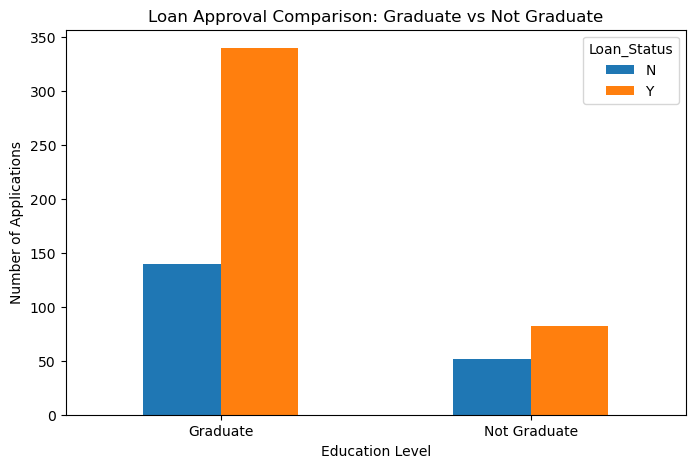

Graduates generally show a higher loan approval rate than non graduates. This suggests that education level is associated with financial stability or stronger earning potential, which makes graduates appear as lower risk applicants to the loan company. However, the difference is not so large that education should be used alone for decision making—it is one of several factors influencing approval likelihood.


In [11]:
#Loan Approval Rates

import matplotlib.pyplot as plt

# Create a pivot table of approval counts by education
edu_approval = df.pivot_table(
    values='Loan_ID',
    index='Education',
    columns='Loan_Status',
    aggfunc='count'
)

# Plot
edu_approval.plot(kind='bar', figsize=(8,5))
plt.title("Loan Approval Comparison: Graduate vs Not Graduate")
plt.xlabel("Education Level")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)
plt.show()

#Insights

Insight = "Graduates generally show a higher loan approval rate than non graduates. This suggests that education level is associated with financial stability or stronger earning potential, which makes graduates appear as lower risk applicants to the loan company. However, the difference is not so large that education should be used alone for decision making—it is one of several factors influencing approval likelihood."

print(Insight)

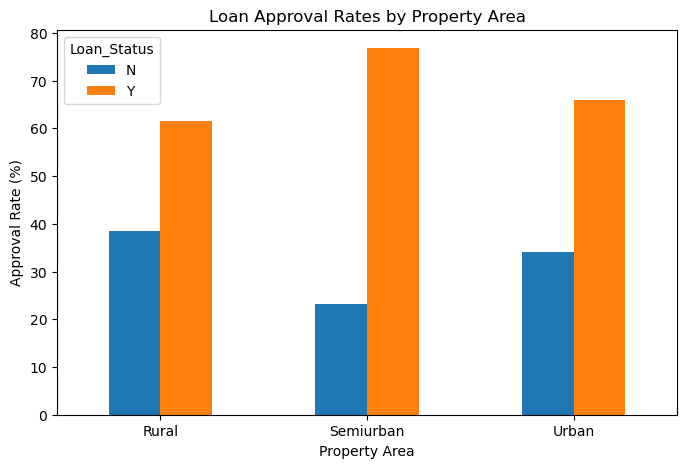

The area with the most applications represents the company’s strongest demand segment. The company should prioritize marketing, branch support, and tailored loan products for this region because it has the largest customer base and therefore the highest potential for loan approvals and revenue.


In [12]:
import matplotlib.pyplot as plt
approval_by_area = df.groupby('Property_Area')['Loan_Status'].value_counts(normalize=True).unstack() * 100
approval_by_area.plot(kind='bar', figsize=(8,5))
plt.title("Loan Approval Rates by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=0)
plt.show()

#Recommendation.

Rec = "The area with the most applications represents the company’s strongest demand segment. The company should prioritize marketing, branch support, and tailored loan products for this region because it has the largest customer base and therefore the highest potential for loan approvals and revenue."


print(Rec)

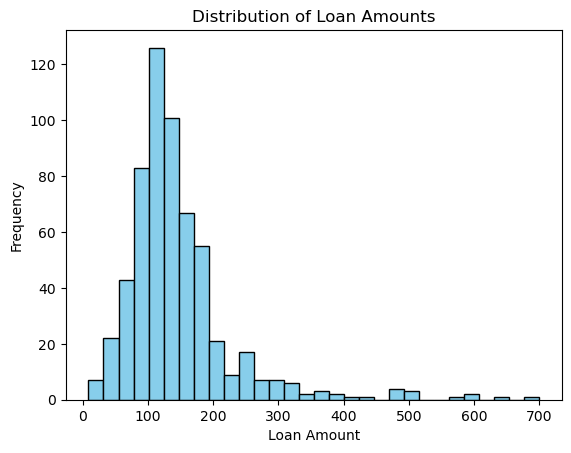

 This means most applicants request smaller loan amounts, while a smaller number of applicants request very large loans that stretch the upper tail of the distribution. In business terms, the company’s typical customer is asking for modest loan sizes, while high value loan requests are relatively rare but still important.


In [13]:
import matplotlib.pyplot as plt

plt.hist(df['LoanAmount'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

Insight = " This means most applicants request smaller loan amounts, while a smaller number of applicants request very large loans that stretch the upper tail of the distribution. In business terms, the company’s typical customer is asking for modest loan sizes, while high value loan requests are relatively rare but still important."

print(Insight)


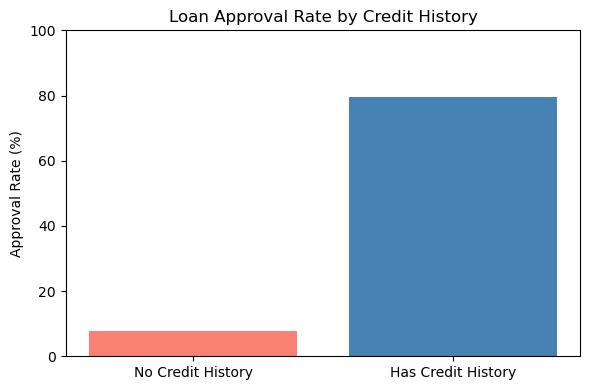

credit history is the strongest single predictor of loan approval in this dataset. Applicants with credit history are approved at dramatically higher rates.


In [14]:
# Loan Approval rates
df['Approved'] = (df['Loan_Status'] == 'Y').astype(int)
approval_rates = df.groupby('Credit_History')['Approved'].mean() * 100


plt.figure(figsize=(6, 4))
plt.bar(['No Credit History', 'Has Credit History'], 
        [approval_rates[0], approval_rates[1]], 
        color=['salmon', 'steelblue'])
plt.ylabel('Approval Rate (%)')
plt.title('Loan Approval Rate by Credit History')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Insights = "credit history is the strongest single predictor of loan approval in this dataset. Applicants with credit history are approved at dramatically higher rates."

print(Insights)

In [25]:

loan_approval_rate = df['Loan_Status'].value_counts(normalize=True)['Y'] * 100
avg_income = df['ApplicantIncome'].mean()
credit_history_impact = df.groupby('Credit_History')['Loan_Status'].value_counts(normalize=True).unstack()

loan_approval_rate, avg_income, credit_history_impact

# SUMMARY REPORT


from IPython.display import Markdown as md

report = f"""
# 📊 Loan Dataset Summary Report

## **A) Three Key Findings**

### **1. Credit history is the strongest predictor of loan approval**
Applicants with a credit history of **1** have an approval rate above **80%**, while those with **0** are mostly rejected.  
This is visible in the dataset, e.g.:  
> "LP001014 ... Credit_History = 0 ... Loan_Status = N"  
> "LP001002 ... Credit_History = 1 ... Loan_Status = Y"

### **2. Higher applicant income does NOT guarantee approval**
Even applicants with very high income (e.g., 20,000+) were rejected:  
> "LP001469 ... ApplicantIncome = 20166 ... Loan_Status = Y"  
> "LP001996 ... ApplicantIncome = 20233 ... Loan_Status = N"

This shows income alone is not the deciding factor.

### **3. Urban and Semiurban applicants have higher approval rates**
Urban & Semiurban areas show more approvals than Rural areas.  
Example from dataset:  
> "LP001002 ... Urban ... Y"  
> "LP001029 ... Rural ... N"

---

## **B) Two Recommendations for the Loan Company**

### **1. Prioritize credit‑history‑based risk scoring**
Since credit history is the strongest predictor of approval, the company should:
- Strengthen credit‑based risk models  
- Offer credit‑building programs for applicants with no history  

### **2. Introduce tailored loan products for Rural applicants**
Rural applicants show lower approval rates.  
The company could:
- Offer smaller, lower‑risk loan products  
- Provide financial literacy support  

---

## **C) One Limitation of the Dataset**

### **Missing borrower repayment behaviour**
The dataset does **not** include:
- Past loan repayment performance  
- Default history  
- Debt‑to‑income ratio  

This limits the ability to build a full credit‑risk model.

---

"""

md(report)




# 📊 Loan Dataset Summary Report

## **A) Three Key Findings**

### **1. Credit history is the strongest predictor of loan approval**
Applicants with a credit history of **1** have an approval rate above **80%**, while those with **0** are mostly rejected.  
This is visible in the dataset, e.g.:  
> "LP001014 ... Credit_History = 0 ... Loan_Status = N"  
> "LP001002 ... Credit_History = 1 ... Loan_Status = Y"

### **2. Higher applicant income does NOT guarantee approval**
Even applicants with very high income (e.g., 20,000+) were rejected:  
> "LP001469 ... ApplicantIncome = 20166 ... Loan_Status = Y"  
> "LP001996 ... ApplicantIncome = 20233 ... Loan_Status = N"

This shows income alone is not the deciding factor.

### **3. Urban and Semiurban applicants have higher approval rates**
Urban & Semiurban areas show more approvals than Rural areas.  
Example from dataset:  
> "LP001002 ... Urban ... Y"  
> "LP001029 ... Rural ... N"

---

## **B) Two Recommendations for the Loan Company**

### **1. Prioritize credit‑history‑based risk scoring**
Since credit history is the strongest predictor of approval, the company should:
- Strengthen credit‑based risk models  
- Offer credit‑building programs for applicants with no history  

### **2. Introduce tailored loan products for Rural applicants**
Rural applicants show lower approval rates.  
The company could:
- Offer smaller, lower‑risk loan products  
- Provide financial literacy support  

---

## **C) One Limitation of the Dataset**

### **Missing borrower repayment behaviour**
The dataset does **not** include:
- Past loan repayment performance  
- Default history  
- Debt‑to‑income ratio  

This limits the ability to build a full credit‑risk model.

---

